In [1]:
import numpy as np
import pandas as pd
import torch
from connectome_interpreter import *
from nglscenes import *
import scipy as sp
from tqdm import tqdm
import plotly.express as px
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
import re

from typing import Iterable, Union, Optional, Callable

In [2]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
cell_type_to_function_df = pd.read_csv(
    "~/Downloads/known_types_snapshots/known_types_311225.csv"
)
cell_type_to_function = dict(
    zip(cell_type_to_function_df.cell_type, cell_type_to_function_df.known_function)
)

In [4]:
inprop = sp.sparse.load_npz("data/fafb_all_neuron/fafb_inprop_all_neuron.npz")
syncount = sp.sparse.load_npz("data/fafb_all_neuron/fafb_syncount_all_neuron.npz")
# axo-dendritic
ad_inprop = sp.sparse.load_npz("data/fafb_all_neuron/fafb_ad_inprop_all_neuron.npz")
ad_syncount = sp.sparse.load_npz("data/fafb_all_neuron/fafb_ad_syncount_all_neuron.npz")

meta = pd.read_csv("data/fafb_all_neuron/fafb_all_neuron_meta.csv", index_col=0)
meta['type_side'] = meta.cell_type + "_" + meta.side

idx_to_type = dict(zip(meta.idx, meta.cell_type))
idx_to_type_side = dict(zip(meta.idx, meta.cell_type + "_" + meta.side))
type_to_sign = dict(zip(meta.cell_type, meta.sign))
idx_to_sign = dict(zip(meta.idx, meta.sign))
type_side_to_sign = dict(zip(meta.cell_type + "_" + meta.side, meta.sign))
idx_to_class = dict(zip(meta.idx, meta.cell_class))
idx_to_coords = dict(zip(meta.idx, meta.coords))
idx_to_root = dict(zip(meta.idx, meta.root_id.astype(str)))
root_to_type = dict(zip(meta.root_id.astype(str), meta.cell_type))
type_to_class = dict(zip(meta.cell_type, meta.cell_class))
type_to_super_class = dict(zip(meta.cell_type, meta.super_class))

meta.loc[meta.cell_type.isin(cell_type_to_function), "known_function"] = meta[
    meta.cell_type.isin(cell_type_to_function)
].cell_type.map(cell_type_to_function)
meta.known_function.fillna(meta.cell_type, inplace=True)
idx_to_function = dict(zip(meta.idx, meta.known_function))
function_to_sign = dict(zip(meta.known_function, meta.sign))
function_to_super_class = dict(zip(meta.known_function, meta.super_class))
function_to_cell_class = dict(zip(meta.known_function, meta.cell_class))

idx_to_lineage = dict(zip(meta.idx, meta.ito_lee_hemilineage))

C:\Users\44745\AppData\Local\Temp\ipykernel_136084\1384816554.py:7: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv("data/fafb_all_neuron/fafb_all_neuron_meta.csv", index_col=0)
C:\Users\44745\AppData\Local\Temp\ipykernel_136084\1384816554.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta.known_function.fillna(meta.cell_type, inplace=True)


In [5]:
meta.loc[meta.cell_type.str.contains('ORN'), ["glomerulus"]] = meta.loc[
    meta.cell_type.str.contains("ORN"), "cell_type"
].str.replace("ORN_", "")

idx_to_glomeruli = dict(zip(meta.idx, meta.glomerulus))
type_to_glomerulus = dict(zip(meta.cell_type, meta.glomerulus))

In [6]:
inprop_signed = add_sign(inprop, idx_to_sign)
# ad_inprop_signed = add_sign(ad_inprop, idx_to_sign)

In [7]:
door = load_dataset("DoOR_adult")
door.columns = [col.split("_")[0] for col in door.columns]

In [ ]:
# get intermediate neurons 
target_type = 'SMP108'
orns = meta.idx[meta.cell_class == 'olfactory']
target = meta.idx[(meta.cell_type == target_type)]
el = el_within_n_steps(
    inprop, orns, target, 5, 0.01, pre_group=idx_to_type, post_group=idx_to_type
)

 40%|████      | 2/5 [00:01<00:02,  1.08it/s]

No edges left in the last layer after thresholding.Try lowering the threshold.


100%|██████████| 5/5 [00:15<00:00,  3.12s/it]


## model definition

In [9]:
num_layers = 6

In [10]:
# input definition
sensory_indices = sorted(list(set(meta.idx[meta.cell_class == "olfactory"])))  # all ORN

ms = []
odour = "ethanol"
glom2act = dict(door.loc[:, door.columns == odour].reset_index().values)
v = np.array(
    [
        glom2act[idx_to_glomeruli[idx]] if idx_to_glomeruli[idx] in glom2act else 0
        for idx in sensory_indices
    ]
)
m = np.zeros((len(sensory_indices), num_layers), dtype=np.float32)
# put v in all columns of m
m[:, 0:5] = v[:, np.newaxis]

ms.append(m)

d_in = np.stack(ms)
d_in_tensor = torch.tensor(d_in, requires_grad=True)

In [11]:
# model definition
model = MultilayeredNetwork(
    inprop_signed,
    sensory_indices,
    threshold=0,
    tanh_steepness=3,
    num_layers=num_layers,
)

## gradients (saliency)

In [12]:
target_index = meta.idx[(meta.cell_type == target_type) & (meta.side == 'left')]
target_types = {
    5: target_index, # one neuron 
}

gradients = get_gradients(
    model,
    d_in_tensor,
    meta.idx[meta.cell_type.isin(el.post)],
    target_types,
    monitor_layers=range(max(target_types.keys()) + 1),
    # idx_to_group=idx_to_type,
    batch_names=[odour],
)
gradients

layer,group,batch_name,time_0,time_1,time_2,time_3,time_4,time_5
0,69,ethanol,0.000018,0.000010,0.000011,-2.546300e-06,0.0,0.0
1,72,ethanol,0.000001,-0.000006,-0.000010,3.422484e-06,0.0,0.0
2,83,ethanol,0.000099,0.000060,0.000021,5.835981e-06,0.0,0.0
3,105,ethanol,0.000017,-0.000016,0.000029,-1.249703e-05,0.0,0.0
4,114,ethanol,0.000001,-0.000007,-0.000009,3.894042e-07,0.0,0.0
...,...,...,...,...,...,...,...,...
10123,138785,ethanol,0.000078,-0.000060,0.000009,3.549982e-06,0.0,0.0
10124,138823,ethanol,0.000180,-0.000260,-0.000509,6.692532e-04,0.0,0.0
10125,139008,ethanol,0.000055,0.000075,0.000501,-8.888262e-04,0.0,0.0
10126,139058,ethanol,-0.000029,-0.000037,-0.000097,3.116712e-05,0.0,0.0


In [13]:
out = model(d_in)

## manipulation

In [14]:
original_acts = get_neuron_activation(
    out,
    meta.idx[meta.cell_type.isin(el.post) | meta.idx.isin(target_index)],
    [odour],
)
acts_l = original_acts.melt(
    id_vars=["batch_name", "group"], var_name="time", value_name="activation"
)
acts_l['time'] = acts_l.time.str.replace('time_', '').astype(int)
# make a dictionary of {time: {group: activation}}
acts_dict = {}
for t in acts_l.time.unique():
    acts_dict[t] = dict(acts_l[acts_l.time == t][['group', 'activation']].values)

In [15]:
acts = []
# add a little bit to all activations
for little in [
    1e-6, 1e-5, 1e-4, 0.001, 0.01, 0.1, 0.5, 1.0]:
    this_acts_dict = {t: {} for t in acts_dict}

    for t in acts_dict:
        for g in acts_dict[t]:
            this_acts_dict[t][g] = min(acts_dict[t][g] + little, 1.0)

    for ctype in tqdm(el.post.unique()[0:150]): 
        for idx in meta.idx[meta.cell_type == ctype]:
                
            for l in range(5):
                out = model(
                    d_in,
                    manipulate={l: {idx: this_acts_dict[l][idx]}},
                )
                fbnact = get_neuron_activation(
                    out,
                    target_index, 
                    [odour],
                )
                fbnact['manipulated_idx'] = idx
                fbnact['manipulated_ctype'] = ctype
                fbnact['manipulate_layer'] = l
                fbnact['little_added'] = little
                acts.append(fbnact)

acts_all = pd.concat(acts, ignore_index=True)

100%|██████████| 150/150 [30:01<00:00, 12.01s/it]


In [ ]:
# merging the two so that we can calculate the difference in target activation
acts_all_l = acts_all.melt(
    id_vars=["batch_name", "group", "manipulated_idx", "manipulated_ctype", "manipulate_layer", 'little_added'], var_name="time", value_name="activation"
)
# time here refers to the activation time for the cell type in group
# has activation of many neurons 
original_acts_l = original_acts.melt(
    id_vars=["batch_name", "group"], var_name="time", value_name="activation"
)

# has activation of only the target 
acts_little = original_acts_l.merge(
    acts_all_l,
    left_on=["batch_name", "group", "time"],
    right_on=["batch_name", "group", "time"],
    suffixes=("_original", "_manipulated"),
)
# target activity time 
acts_little["time"] = acts_little.time.str.replace("time_", "")
acts_little["activation_diff"] = (
    acts_little.activation_manipulated - acts_little.activation_original
)
acts_little["manipulate_layer"] = acts_little.manipulate_layer.astype(str)

acts_little

,batch_name,group,time,activation_original,manipulated_idx,manipulated_ctype,manipulate_layer,little_added,activation_manipulated,activation_diff
0,ethanol,102611,0,0.000000,86669,CB1423,0,0.000001,0.000000,0.000000e+00
1,ethanol,102611,0,0.000000,86669,CB1423,1,0.000001,0.000000,0.000000e+00
2,ethanol,102611,0,0.000000,86669,CB1423,2,0.000001,0.000000,0.000000e+00
3,ethanol,102611,0,0.000000,86669,CB1423,3,0.000001,0.000000,0.000000e+00
4,ethanol,102611,0,0.000000,86669,CB1423,4,0.000001,0.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
165595,ethanol,102611,5,0.012556,78862,CB1247,0,1.000000,0.012562,6.274320e-06
165596,ethanol,102611,5,0.012556,78862,CB1247,1,1.000000,0.012544,-1.222920e-05
165597,ethanol,102611,5,0.012556,78862,CB1247,2,1.000000,0.012563,7.062219e-06
165598,ethanol,102611,5,0.012556,78862,CB1247,3,1.000000,0.012568,1.198705e-05


In [27]:
acts_little.to_csv("saliency_results.csv")

In [ ]:
acts_little = pd.read_csv("saliency_results.csv", index_col=0)

In [17]:
acts_little['time'] = acts_little.time.astype(str)
acts_little['manipulate_layer'] = acts_little.manipulate_layer.astype(str)
acts_little["manipulated_idx"] = acts_little.manipulated_idx.astype(int)

## effective connectivity

In [18]:
# calculate effective connectivity
inidx = meta.idx[meta.idx.isin(acts_little.manipulated_idx)]
effconn = conn_by_path_length_data(
    inprop, inidx, target_index, 5, inidx_map={idx: idx for idx in meta.idx}
)
effconn.pre = effconn.pre.astype(int)

100%|██████████| 5/5 [01:13<00:00, 14.73s/it]


In [19]:
# calculate signed effective connectivity
inidx = meta.idx[meta.idx.isin(acts_little.manipulated_idx)]
es = []
inhibs = []
eminusi = []
for i in tqdm(range(5)): 
    paths = find_paths_of_length(inprop, inidx, target_index, i + 1)
    # paths = group_paths(paths, idx_to_type, idx_to_type)
    e, inhib = signed_effective_conn_from_paths(paths, idx_to_nt=idx_to_sign)
    if len(e) >0:
        e = e.reset_index()
        e.columns = ['pre', 'excitation']
        e['path_length'] = i + 1
        es.append(e)
    if len(inhib) > 0: 
        inhib = inhib.reset_index()
        inhib.columns = ['pre', 'inhibition']
        inhib['path_length'] = i + 1

        inhibs.append(inhib)

es = pd.concat(es)
inhibs = pd.concat(inhibs)

ei = es.merge(inhibs, on=["pre", "path_length"], how="outer").fillna(0)

ei["time"] = 5 - ei.path_length
ei["time"] = ei["time"].astype(str)
ei["ei_sum"] = ei.excitation + ei.inhibition
ei["ei_diff"] = ei.excitation - ei.inhibition

100%|██████████| 5/5 [00:37<00:00,  7.48s/it]


## all together

In [69]:
# gradients of intermediate neurons, for each odour, across time
# has columns: group, batch_name, time, gradient
gradients_long = gradients.melt(
    id_vars=["group", "batch_name"], var_name="time", value_name="gradient"
)
gradients_long["time"] = gradients_long["time"].str.replace("time_", "")

# effective connectivity from intermediate neurons, across path lengths
# has columns: pre, weight, path_length
effconn["time"] = 5 - effconn.path_length
effconn["time"] = effconn["time"].astype(str)
result = gradients_long.merge(
    effconn, left_on=["group", "time"], right_on=["pre", "time"]
)
# signed effective connectivity
# has columns: pre, excitation, inhibition, ei_sum, path_length
result = result.drop("pre", axis=1).merge(
    ei.loc[:, ei.columns != "path_length"],
    left_on=["group", "time"],
    right_on=["pre", "time"],
)
result['path_length'] = result['path_length'].astype(str)

# time column is from gradients, and refers to the measured gradient for the intermediate neuron

# difference in activation if small step size
# has columns: batch_name, manipulated, time, manipulation_layer
result = result.merge(
    # gradients were measured for timepoint 5, so let's only take activity of target at time = 5
    acts_little[acts_little.time == "5"].drop(["group", 'time'], axis=1),
    left_on=["batch_name", "group", "time"],
    right_on=["batch_name", "manipulated_idx", "manipulate_layer"],
)
result.drop('pre', axis = 1)

,group,batch_name,time,gradient,path_length,weight,excitation,inhibition,ei_sum,ei_diff,activation_original,manipulated_idx,manipulated_ctype,manipulate_layer,little_added,activation_manipulated,activation_diff
0,140,ethanol,0,0.000190,5,0.000189,0.000094,0.000095,0.000189,-8.017960e-07,0.012556,140,DA1_lPN,0,0.000001,0.012556,0.000000e+00
1,140,ethanol,0,0.000190,5,0.000189,0.000094,0.000095,0.000189,-8.017960e-07,0.012556,140,DA1_lPN,0,0.000010,0.012556,0.000000e+00
2,140,ethanol,0,0.000190,5,0.000189,0.000094,0.000095,0.000189,-8.017960e-07,0.012556,140,DA1_lPN,0,0.000100,0.012556,1.676381e-08
3,140,ethanol,0,0.000190,5,0.000189,0.000094,0.000095,0.000189,-8.017960e-07,0.012556,140,DA1_lPN,0,0.001000,0.012556,1.899898e-07
4,140,ethanol,0,0.000190,5,0.000189,0.000094,0.000095,0.000189,-8.017960e-07,0.012556,140,DA1_lPN,0,0.010000,0.012558,1.882203e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22827,138204,ethanol,4,0.001134,1,0.000378,0.000378,0.000000,0.000378,3.781076e-04,0.012556,138204,CB0233,4,0.001000,0.012557,1.131557e-06
22828,138204,ethanol,4,0.001134,1,0.000378,0.000378,0.000000,0.000378,3.781076e-04,0.012556,138204,CB0233,4,0.010000,0.012567,1.133978e-05
22829,138204,ethanol,4,0.001134,1,0.000378,0.000378,0.000000,0.000378,3.781076e-04,0.012556,138204,CB0233,4,0.100000,0.012669,1.134118e-04
22830,138204,ethanol,4,0.001134,1,0.000378,0.000378,0.000000,0.000378,3.781076e-04,0.012556,138204,CB0233,4,0.500000,0.013123,5.670656e-04


In [70]:
# correlation between gradient, ei_diff, and activation difference 
corrs = result.groupby(["path_length", "little_added"])[
    ["gradient", "ei_diff", "activation_diff"]
].corr().reset_index()
corrs = corrs.melt(
    id_vars=["path_length", "little_added", "level_2"],
    value_vars=["gradient", "ei_diff", "activation_diff"],
    var_name="var2",
    value_name="correlation",
).rename(columns={"level_2": "var1"})
corrs = corrs[corrs.var1 != corrs.var2]
corrs['path_length'] = corrs['path_length'].astype(str)

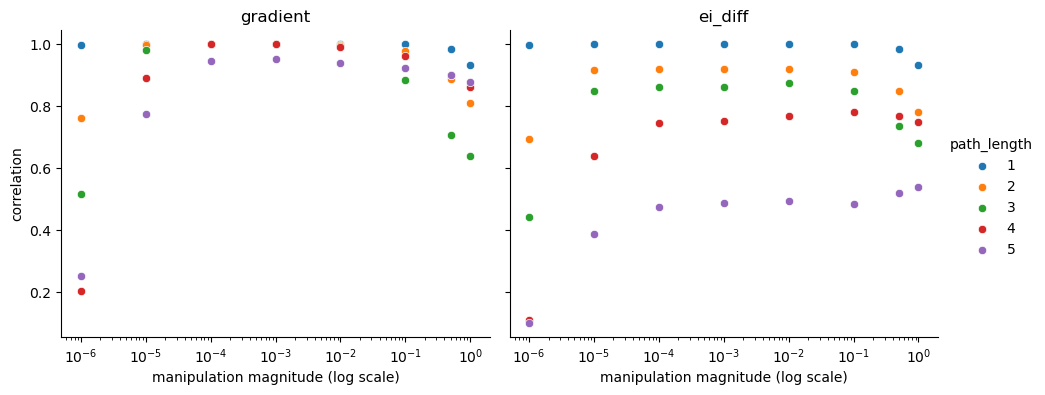

In [ ]:
df = corrs[corrs.var2 == "activation_diff"]

g = sns.FacetGrid(
    df,
    col="var1",
    hue="path_length",
    sharey=True,
    height=4,
    aspect=1.2,
)

g.map_dataframe(
    sns.scatterplot,
    x="little_added",
    y="correlation",
)

g.set(xscale="log", xlabel='manipulation magnitude (log scale)')
g.add_legend(title="path_length")

for ax, v in zip(g.axes.flat, g.col_names):
    ax.set_title(f"{v}")

plt.show()

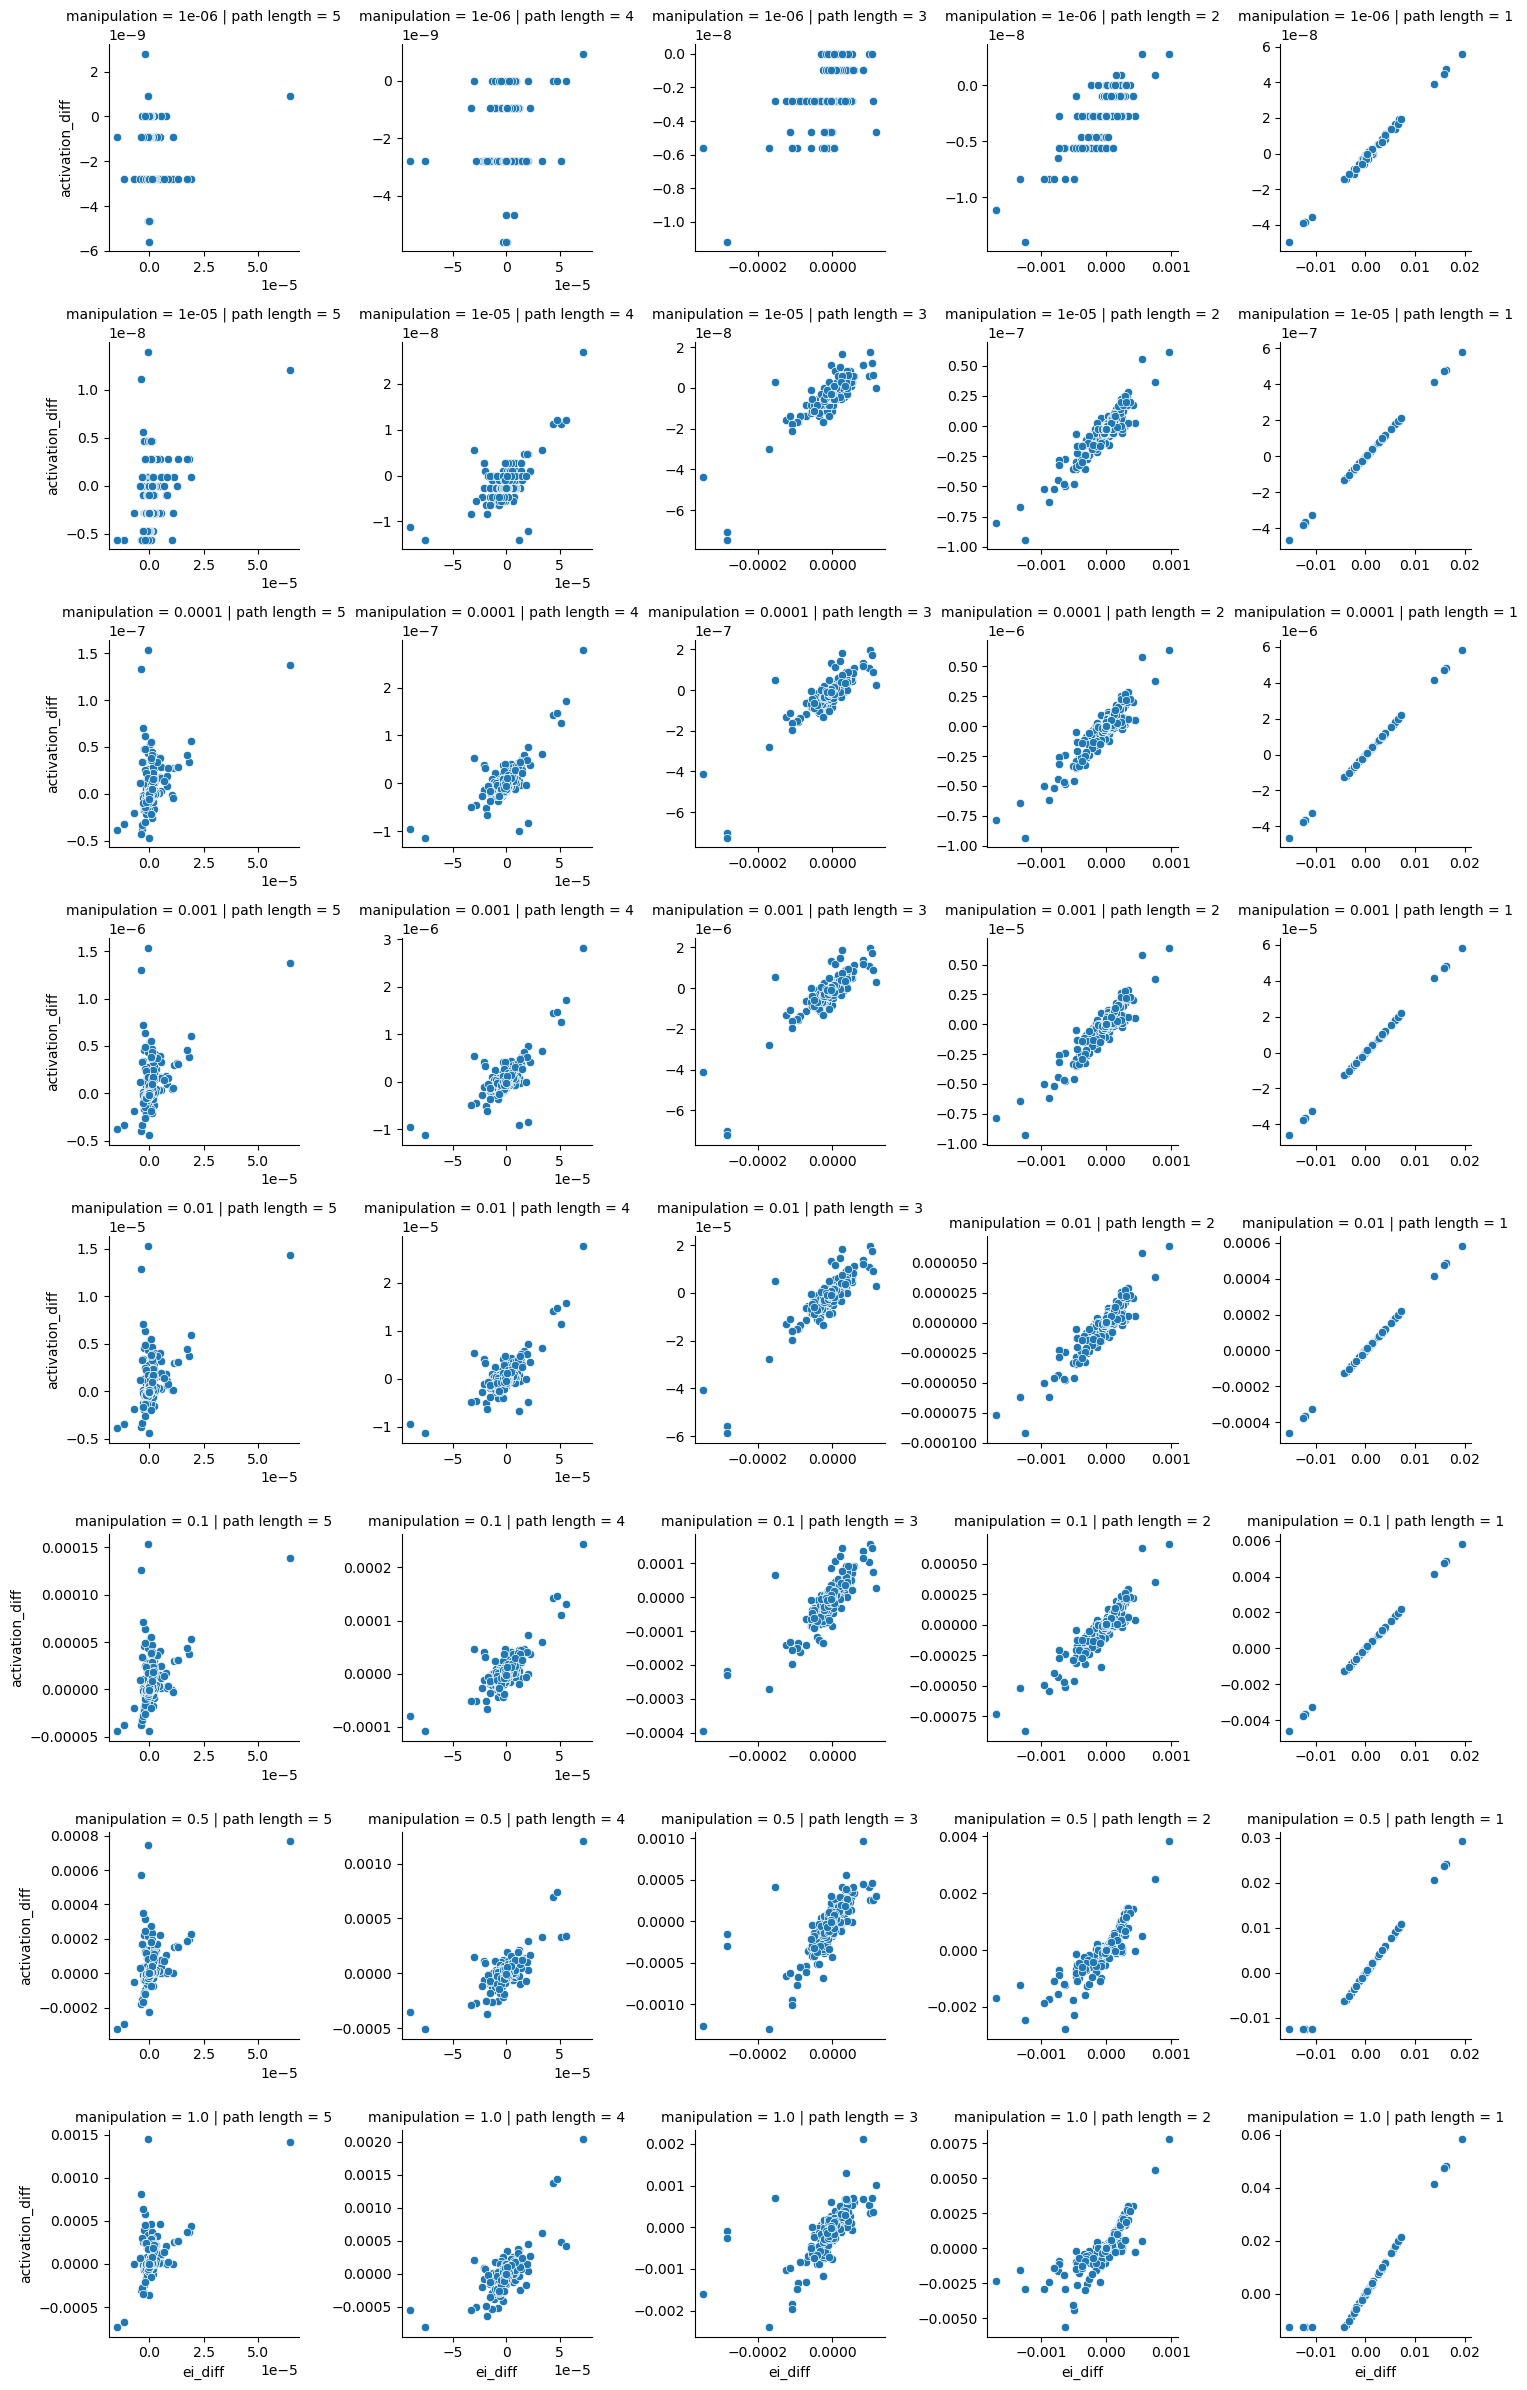

In [75]:
g = sns.FacetGrid(
    result,
    row="little_added",
    col="path_length",
    sharex=False,
    sharey=False,
    # height=3,
    # aspect=1.2,
)

g.map_dataframe(
    sns.scatterplot,
    x="ei_diff",
    y="activation_diff",
)

g.set_axis_labels("ei_diff", "activation_diff")
g.set_titles(
    row_template="manipulation = {row_name}", col_template="path length = {col_name}"
)

plt.tight_layout()
plt.show()

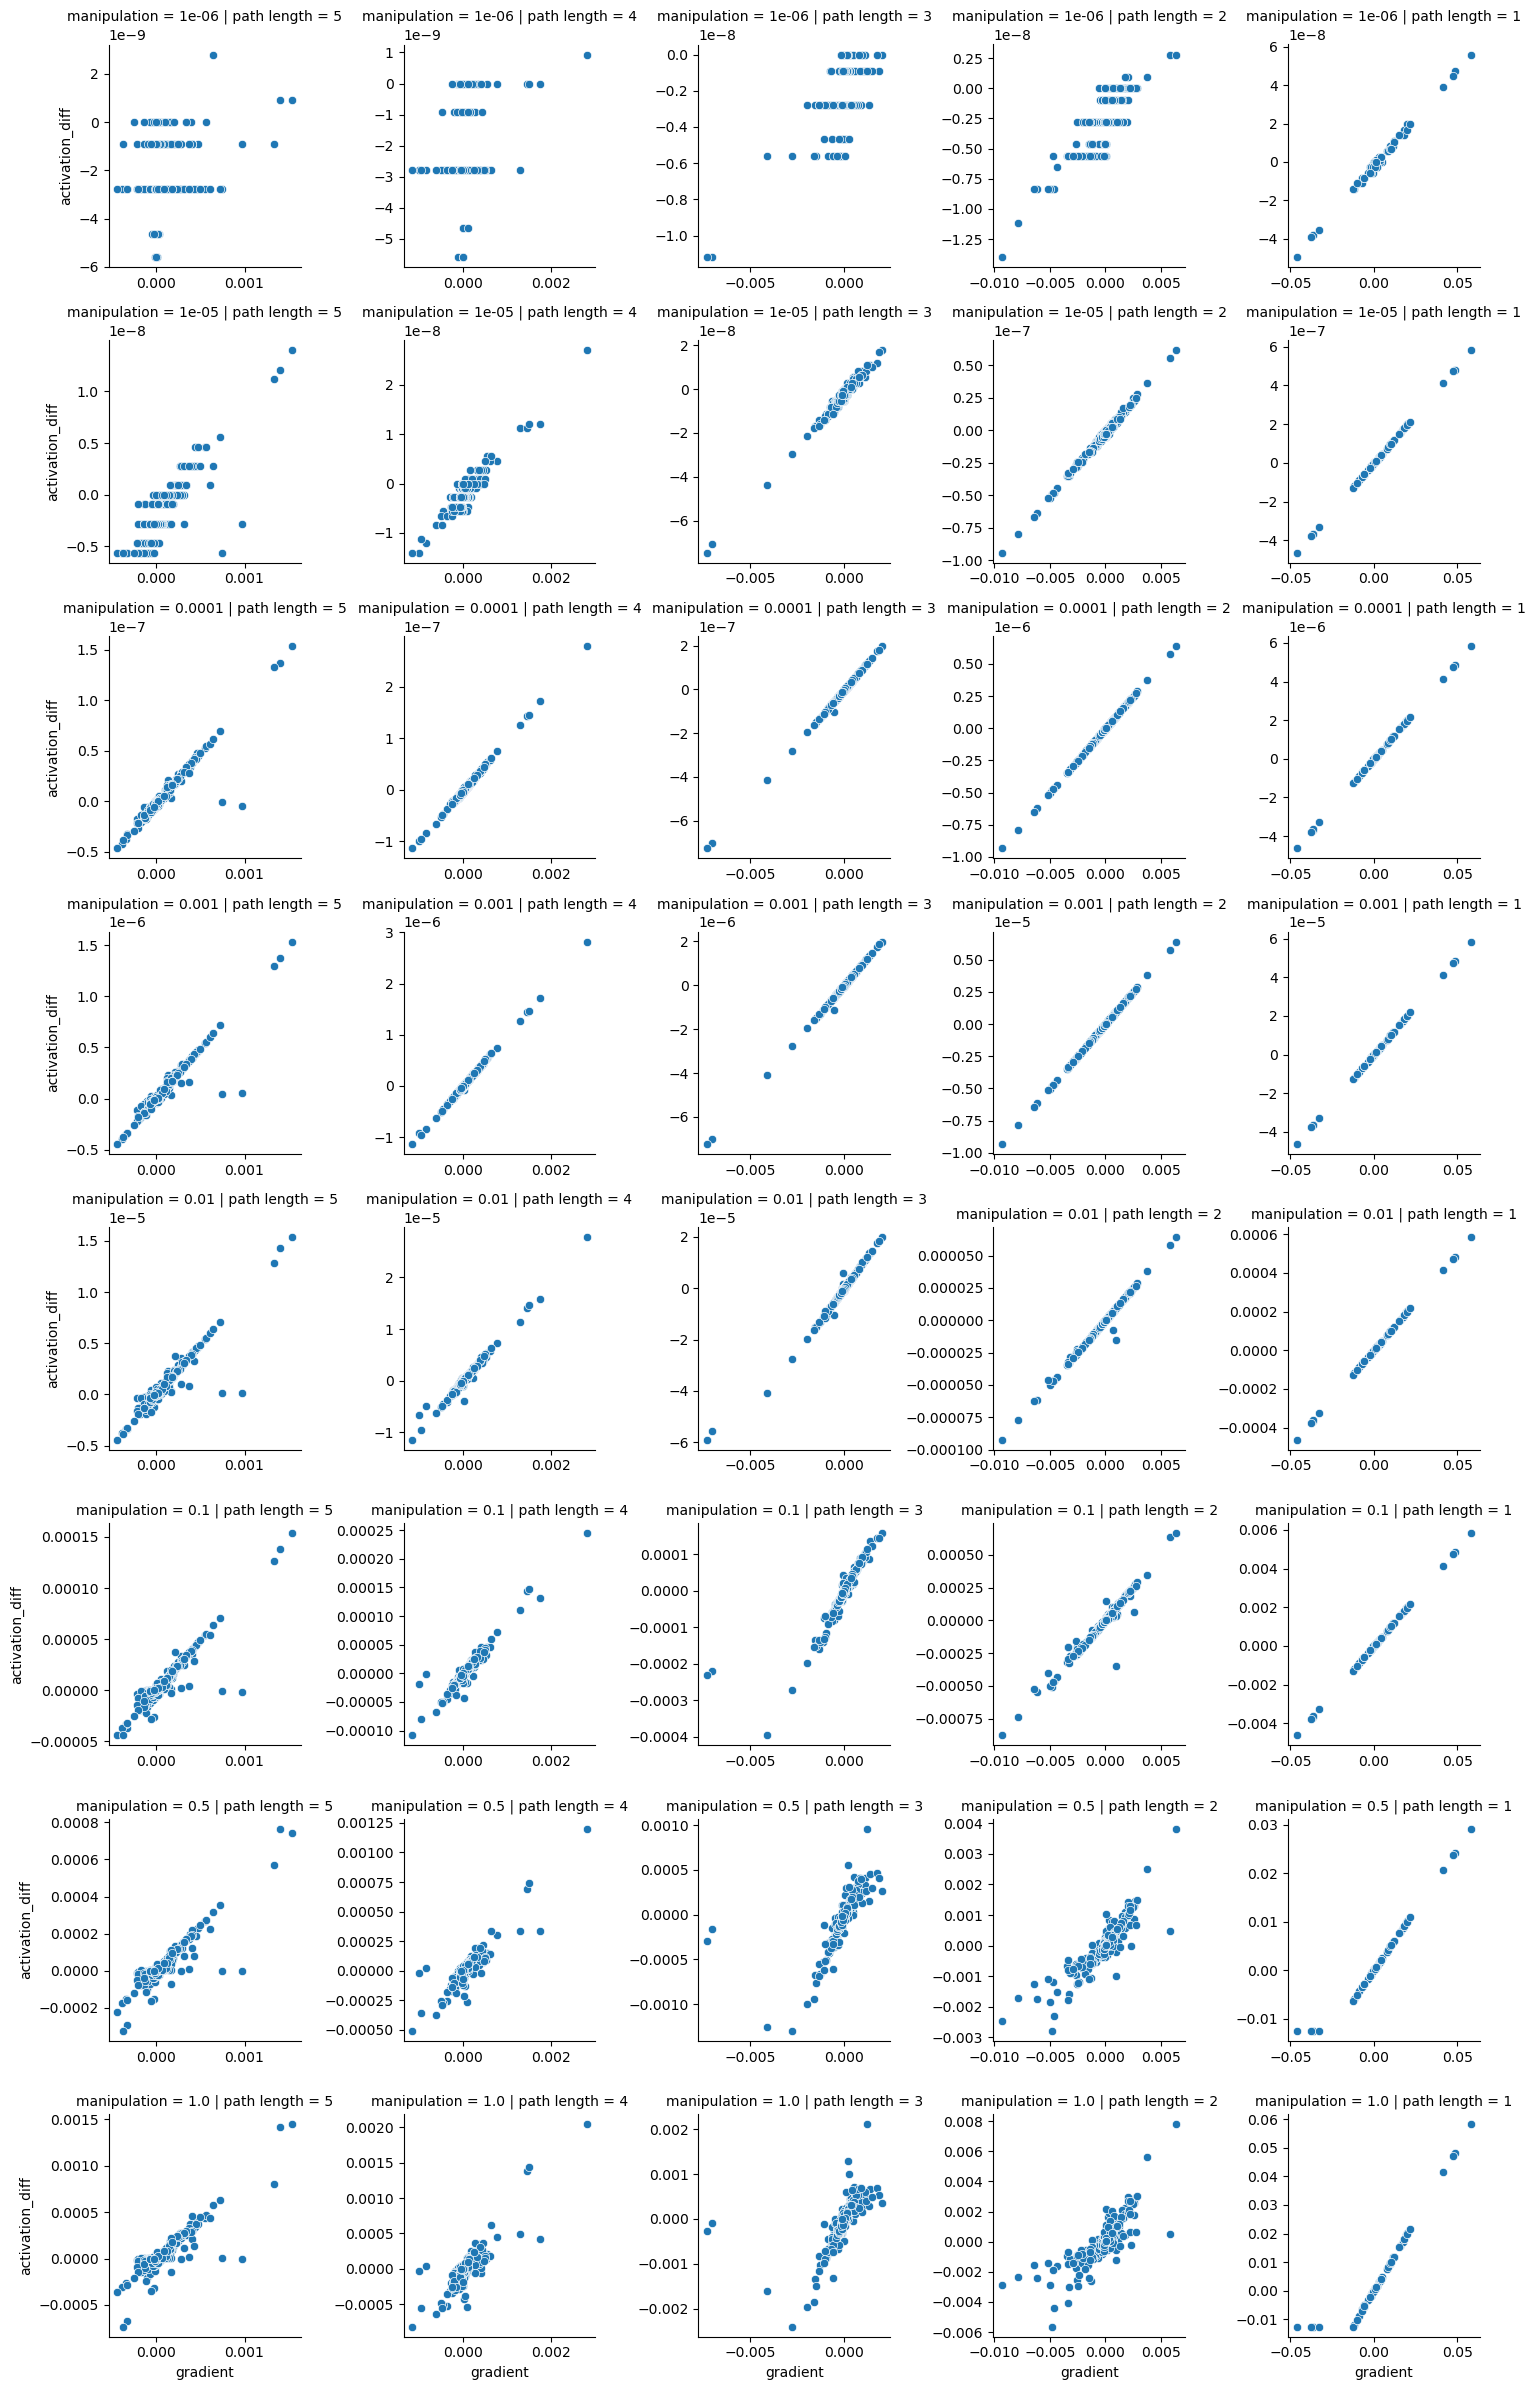

In [76]:

g = sns.FacetGrid(
    result,
    row="little_added",
    col="path_length",
    sharex=False,
    sharey=False,
    # height=3,
    # aspect=1.2,
)

g.map_dataframe(
    sns.scatterplot,
    x="gradient",
    y="activation_diff",
)

g.set_axis_labels("gradient", "activation_diff")
g.set_titles(
    row_template="manipulation = {row_name}", col_template="path length = {col_name}"
)

plt.tight_layout()
plt.show()

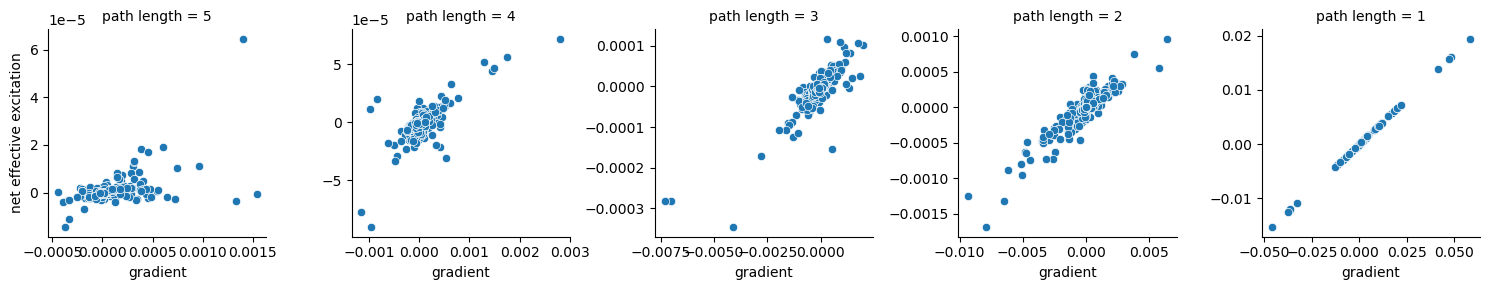

In [78]:
g = sns.FacetGrid(
    # gradient and ei_diff doesn't depend on little_added, so just plot for one value
    result[result.little_added == 0.01],
    # row="little_added",
    col="path_length",
    sharex=False,
    sharey=False,
)

g.map_dataframe(
    sns.scatterplot,
    x="gradient",
    y="ei_diff",
)

g.set_axis_labels("gradient", "net effective excitation")
g.set_titles(
    col_template="path length = {col_name}"
)

plt.tight_layout()
plt.show()